In [ ]:
import numpy as np
import pygame
import sys

# ---------------------------------------------------------
# SIMULATION PARAMETERS
# ---------------------------------------------------------
WIDTH, HEIGHT = 600, 600       # Window & grid size (pixels)
GRID_SCALE = 4                  # Oxygen grid resolution (150x150 cells)
GW, GH = WIDTH // GRID_SCALE, HEIGHT // GRID_SCALE

N_WORMS = 1200                  # Number of worm agents
WORM_SPEED_MAX = 2.5            # Max speed at high O2
WORM_SPEED_MIN = 0.2            # Min speed at target O2 (slow down / trap)
ROTATION_NOISE = 0.3            # Tumbling noise

# Oxygen Fields Parameters
O2_AMBIENT = 0.21               # High ambient O2 = 21% (Try 0.07 for low O2!)
D_O2 = 0.15                     # Oxygen diffusion rate
REPLENISH_RATE = 0.01           # Rate of atmospheric oxygen absorption
DEPLETION_RATE = 0.08           # Rate at which worms consume local O2

# ---------------------------------------------------------
# INITIALIZATION
# ---------------------------------------------------------
pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("C. elegans npr-1 Aerotaxis Simulation")
clock = pygame.time.Clock()

# Worm state: X, Y positions & orientations (theta)
pos = np.random.rand(N_WORMS, 2) * [WIDTH, HEIGHT]
theta = np.random.rand(N_WORMS) * 2 * np.pi

# Oxygen grid initialized to ambient level
O2 = np.full((GH, GW), O2_AMBIENT, dtype=np.float64)

# ---------------------------------------------------------
# SPEED FUNCTION (Speed depends on local O2)
# ---------------------------------------------------------
def get_speed(o2_levels):
    """
    Worms slow down drastically at preferred O2 (~0.08 to 0.10).
    They run fast at high O2 (>0.15) or very low O2 (<0.04).
    """
    # Gaussian-like drop in speed around target O2 = 0.08
    slow_factor = np.exp(-((o2_levels - 0.08) ** 2) / (2 * (0.03 ** 2)))
    return WORM_SPEED_MAX - (WORM_SPEED_MAX - WORM_SPEED_MIN) * slow_factor

# ---------------------------------------------------------
# MAIN LOOP
# ---------------------------------------------------------
running = True
font = pygame.font.SysFont(None, 24)

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            # Toggle Ambient O2 level live with UP/DOWN keys
            if event.key == pygame.K_UP:
                O2_AMBIENT = min(0.30, O2_AMBIENT + 0.03)
            elif event.key == pygame.K_DOWN:
                O2_AMBIENT = max(0.02, O2_AMBIENT - 0.03)

    # 1. DESTRUCTIVE OXYGEN DEPLETION BY WORMS
    gx = (pos[:, 0] // GRID_SCALE).astype(int).clip(0, GW - 1)
    gy = (pos[:, 1] // GRID_SCALE).astype(int).clip(0, GH - 1)
    
    np.add.at(O2, (gy, gx), -DEPLETION_RATE)
    O2 = np.clip(O2, 0.0, 1.0)

    # 2. OXYGEN DIFFUSION & REPLENISHMENT
    # 2D Laplacian approximation for diffusion
    laplacian = (
        np.roll(O2, 1, axis=0) + np.roll(O2, -1, axis=0) +
        np.roll(O2, 1, axis=1) + np.roll(O2, -1, axis=1) - 4 * O2
    )
    O2 += D_O2 * laplacian + REPLENISH_RATE * (O2_AMBIENT - O2)

    # 3. SAMPLE LOCAL OXYGEN FOR EACH WORM
    worm_o2 = O2[gy, gx]

    # 4. UPDATE WORM POSITIONS BASED ON SPEED(O2)
    speeds = get_speed(worm_o2)
    
    # Add random tumbling (rotational diffusion)
    theta += (np.random.rand(N_WORMS) - 0.5) * ROTATION_NOISE
    
    # Update coordinates
    pos[:, 0] += np.cos(theta) * speeds
    pos[:, 1] += np.sin(theta) * speeds

    # Fixed Box Boundary Collision (Reflect worms off walls)
    margin = 5
    mask_x_low = pos[:, 0] < margin
    mask_x_high = pos[:, 0] > WIDTH - margin
    mask_y_low = pos[:, 1] < margin
    mask_y_high = pos[:, 1] > HEIGHT - margin

    pos[mask_x_low, 0] = margin
    pos[mask_x_high, 0] = WIDTH - margin
    pos[mask_y_low, 1] = margin
    pos[mask_y_high, 1] = HEIGHT - margin

    theta[mask_x_low | mask_x_high] = np.pi - theta[mask_x_low | mask_x_high]
    theta[mask_y_low | mask_y_high] = -theta[mask_y_low | mask_y_high]

    # ---------------------------------------------------------
    # RENDERING
    # ---------------------------------------------------------
    # Draw Oxygen Grid (Blue gradient)
    o2_vis = (O2 / 0.25 * 255).clip(0, 255).astype(np.uint8)
    o2_surface = pygame.surfarray.make_surface(
        np.stack([o2_vis * 0.2, o2_vis * 0.5, o2_vis], axis=-1)
    )
    scaled_bg = pygame.transform.scale(o2_surface, (WIDTH, HEIGHT))
    screen.blit(scaled_bg, (0, 0))

    # Draw Worms (Bright dots)
    for p in pos:
        pygame.draw.circle(screen, (255, 230, 150), p.astype(int), 2)

    # UI Overlay
    txt = font.render(f"Ambient O2: {O2_AMBIENT*100:.1f}% (Use UP/DOWN to change)", True, (255, 255, 255))
    screen.blit(txt, (10, 10))

    pygame.display.flip()
    clock.tick(60)

pygame.quit()
sys.exit()

In [9]:
def V_npr1(O):
    """Speed (um/s) vs O2 (%), fit by eye to Fig. 2b (npr-1 on food).
    ~170 at 1%, ~20 between 5 and 15%, ~150 at 21%."""
    sig = lambda x: 1.0 / (1.0 + np.exp(-x))
    return 20.0 + 160.0 * (1.0 - sig((O - 3.0) / 0.8)) + 150.0 * sig((O - 18.0) / 1.5)

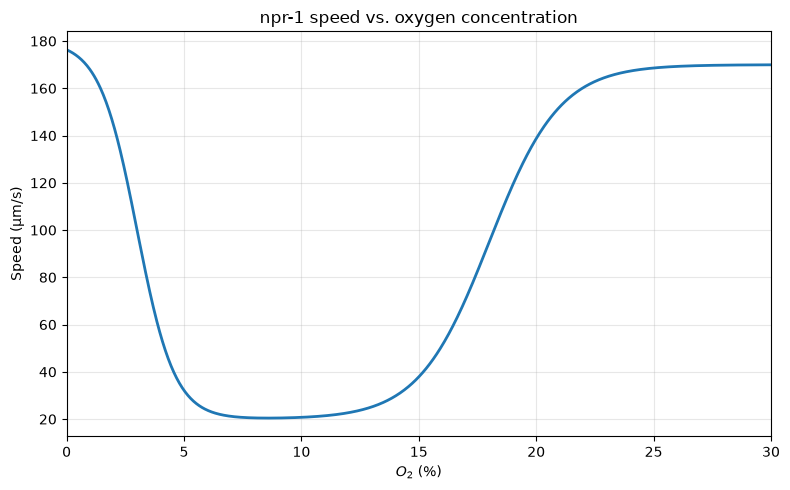

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def V_npr1(O):
    """Speed (um/s) vs O2 (%), fit by eye to Fig. 2b (npr-1 on food)."""
    sig = lambda x: 1.0 / (1.0 + np.exp(-x))
    return 20.0 + 160.0 * (1.0 - sig((O - 3.0) / 0.8)) + 150.0 * sig((O - 18.0) / 1.5)

O = np.linspace(0, 30, 1000)
V = V_npr1(O)

plt.figure(figsize=(8, 5))
plt.plot(O, V, linewidth=2)
plt.xlabel(r"$O_2$ (%)")
plt.ylabel("Speed (µm/s)")
plt.title("npr-1 speed vs. oxygen concentration")
plt.xlim(0, 30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'partial' is not defined